# Solar Cycle Peak Forecasting — Phase 4: Peak Timing Prediction

**Goal:** Predict `Rise_Time_months` — months from cycle start to peak — using early-cycle observations.

**Windows:** 12 months · 24 months · 36 months  
**Models:** Ridge · Random Forest · XGBoost  
**Validation:** Leave-One-Cycle-Out (LOCO) — identical pipeline to Phase 3  
**Checklist:** All Phase 3 leakage rules enforced from the start


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    print("XGBoost not installed — skipping")
    HAS_XGB = False

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

RANDOM_STATE = 42
print(f"Imports OK | XGBoost: {HAS_XGB}")


Imports OK | XGBoost: True


## Load Data

In [38]:
comp = pd.read_csv("../data/Cycle_Database_completed.csv",
                   parse_dates=["Start_Date","End_Date","Peak_Date"])
comp = comp.sort_values("Cycle_ID").reset_index(drop=True)

# Target: months from cycle start to peak
TARGET = "Rise_Time_months"

print(f"Completed cycles : {len(comp)}  (SC1 – SC{int(comp['Cycle_ID'].max())})")
print(f"Rise_Time_months : min={comp[TARGET].min():.1f}  max={comp[TARGET].max():.1f}  mean={comp[TARGET].mean():.1f}")
print(f"NaN in target    : {comp[TARGET].isna().sum()}")
comp[["Cycle_ID","Start_Date","Peak_Date","Rise_Time_months","Peak_Sunspot_Number"]].head(8)


Completed cycles : 24  (SC1 – SC24)
Rise_Time_months : min=35.0  max=82.0  mean=52.3
NaN in target    : 0


,Cycle_ID,Start_Date,Peak_Date,Rise_Time_months,Peak_Sunspot_Number
0,1,1755-02-01,1761-06-01,76.0,144.1
1,2,1766-06-01,1769-09-01,39.0,193.0
2,3,1775-06-01,1778-05-01,35.0,264.2
3,4,1784-09-01,1788-02-01,41.0,235.3
4,5,1798-04-01,1805-02-01,82.0,82.0
5,6,1810-07-01,1816-05-01,70.0,81.2
6,7,1823-05-01,1829-11-01,78.1,119.2
7,8,1833-11-01,1837-03-01,40.0,244.9


## Pipeline (leak-free LOCO)

In [39]:
def get_features(w):
    """Same feature sets as Phase 3."""
    candidates = [
        f"w{w}_mean", f"w{w}_max", f"w{w}_slope", f"w{w}_growth_rate",
        f"w{w}_std", f"w{w}_last",
        f"w{w}_rolling_mean_3", f"w{w}_rolling_mean_6",
        f"w{w}_lag1", f"w{w}_lag3",
        f"w{w}_frac_above_median",
    ]
    if w >= 24:
        candidates += ["w12_mean","w12_max","w12_slope","w12_growth_rate"]
    if w >= 36:
        candidates += ["w24_mean","w24_max","w24_slope"]
    return [c for c in candidates if c in comp.columns and comp[c].notna().all()]


def loco_cv(df, feature_cols, target_col, model_fn):
    """
    Leave-One-Cycle-Out CV.
    - Winsorization: fixed physical bounds [-5, 50] for growth_rate (fold-local, leakage-free)
    - Scaling: RobustScaler fit on training fold only
    """
    growth_indices = [i for i, c in enumerate(feature_cols) if "growth_rate" in c]
    records = []

    for i in df.index:
        train_idx = [j for j in df.index if j != i]
        X_train = df.loc[train_idx, feature_cols].values.copy()
        y_train = df.loc[train_idx, target_col].values
        X_test  = df.loc[[i], feature_cols].values.copy()
        y_test  = df.loc[i, target_col]

        # Winsorize growth_rate — physical bounds, no data leakage
        for idx in growth_indices:
            X_train[:, idx] = np.clip(X_train[:, idx], -5, 50)
            X_test[:, idx]  = np.clip(X_test[:, idx],  -5, 50)

        # Scale — fit on train only
        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model = model_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)[0]

        records.append({
            "Cycle_ID" : int(df.loc[i, "Cycle_ID"]),
            "y_true"   : y_test,
            "y_pred"   : y_pred,
            "error"    : y_pred - y_test,
            "abs_error": abs(y_pred - y_test),
        })
    return pd.DataFrame(records)


def summarise(loco_df, label):
    mae  = mean_absolute_error(loco_df["y_true"], loco_df["y_pred"])
    rmse = np.sqrt(mean_squared_error(loco_df["y_true"], loco_df["y_pred"]))
    r2   = r2_score(loco_df["y_true"], loco_df["y_pred"])
    return {"Model": label, "MAE": round(mae,2), "RMSE": round(rmse,2), "R2": round(r2,4)}


print("Pipeline functions ready.")


Pipeline functions ready.


## Sanity Checks

In [40]:
# LOCO split verification
sample_i  = comp.index[5]
train_idx = [j for j in comp.index if j != sample_i]
print("LOCO Split Verification (sample fold):")
print(f"  Train cycles : {list(comp.loc[train_idx, 'Cycle_ID'].astype(int))}")
print(f"  Test  cycle  : {int(comp.loc[sample_i, 'Cycle_ID'])}")
assert int(comp.loc[sample_i, 'Cycle_ID']) not in list(comp.loc[train_idx, 'Cycle_ID'].astype(int))
print("  Assertion passed — test cycle absent from training fold")
print()
print(f"Target range  : {comp[TARGET].min():.1f} – {comp[TARGET].max():.1f} months")
print(f"Target std    : {comp[TARGET].std():.1f} months")
print(f"Baseline MAE (predict mean): {(comp[TARGET] - comp[TARGET].mean()).abs().mean():.2f} months")


LOCO Split Verification (sample fold):
  Train cycles : [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  Test  cycle  : 6
  Assertion passed — test cycle absent from training fold

Target range  : 35.0 – 82.0 months
Target std    : 13.6 months
Baseline MAE (predict mean): 11.12 months


## Run LOCO CV

In [41]:
models = {
    "Ridge"        : lambda: Ridge(alpha=10.0),
    "RandomForest" : lambda: RandomForestRegressor(n_estimators=300, max_depth=4,
                                                    min_samples_leaf=2, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models["XGBoost"] = lambda: XGBRegressor(n_estimators=200, max_depth=3,
                                              learning_rate=0.05, subsample=0.8,
                                              colsample_bytree=0.8, random_state=RANDOM_STATE,
                                              verbosity=0)

all_results    = []
all_loco_preds = {}

for w in [12, 24, 36]:
    feats = get_features(w)
    for mname, mfn in models.items():
        label   = f"w{w}_{mname}"
        loco_df = loco_cv(comp, feats, TARGET, mfn)
        all_loco_preds[(w, mname)] = loco_df
        row = summarise(loco_df, label)
        all_results.append(row)
        print(f"  {label:<25s}  MAE={row['MAE']:5.2f}  RMSE={row['RMSE']:5.2f}  R²={row['R2']:6.4f}")

results_df = pd.DataFrame(all_results).sort_values("RMSE")
print()
print(results_df.to_string(index=False))


  w12_Ridge                  MAE= 9.71  RMSE=12.51  R²=0.1203
  w12_RandomForest           MAE=10.17  RMSE=13.25  R²=0.0130
  w12_XGBoost                MAE= 9.75  RMSE=13.17  R²=0.0247
  w24_Ridge                  MAE= 7.59  RMSE= 9.34  R²=0.5095
  w24_RandomForest           MAE= 6.39  RMSE= 8.03  R²=0.6370
  w24_XGBoost                MAE= 7.42  RMSE= 9.35  R²=0.5087
  w36_Ridge                  MAE= 7.18  RMSE= 9.17  R²=0.5266
  w36_RandomForest           MAE= 5.96  RMSE= 7.57  R²=0.6772
  w36_XGBoost                MAE= 6.02  RMSE= 8.14  R²=0.6273

           Model   MAE  RMSE     R2
w36_RandomForest  5.96  7.57 0.6772
w24_RandomForest  6.39  8.03 0.6370
     w36_XGBoost  6.02  8.14 0.6273
       w36_Ridge  7.18  9.17 0.5266
       w24_Ridge  7.59  9.34 0.5095
     w24_XGBoost  7.42  9.35 0.5087
       w12_Ridge  9.71 12.51 0.1203
     w12_XGBoost  9.75 13.17 0.0247
w12_RandomForest 10.17 13.25 0.0130


## Extended Evaluation

In [42]:
print("=" * 65)
print("  EXTENDED EVALUATION — fold-wise stats & prediction intervals")
print("=" * 65)

best_per_window = {}
for w in [12, 24, 36]:
    w_res  = results_df[results_df["Model"].str.startswith(f"w{w}_")]
    best   = w_res.sort_values("RMSE").iloc[0]["Model"]
    mname  = best.replace(f"w{w}_","")
    best_per_window[w] = mname

    loco       = all_loco_preds[(w, mname)]
    abs_errors = loco["abs_error"].values
    residuals  = loco["error"].values
    ci_low     = np.percentile(residuals, 10)
    ci_high    = np.percentile(residuals, 90)

    print("")
    print(f"Window={w}m  Best={mname}")
    print(f"  MAE={mean_absolute_error(loco['y_true'],loco['y_pred']):.2f}  "
          f"RMSE={np.sqrt(mean_squared_error(loco['y_true'],loco['y_pred'])):.2f}  "
          f"R²={r2_score(loco['y_true'],loco['y_pred']):.4f}")
    print(f"  Fold-wise MAE: mean={abs_errors.mean():.2f}, std={abs_errors.std():.2f} months")
    print(f"  80% prediction interval (residuals): [{ci_low:+.1f}, {ci_high:+.1f}] months")

print("")
print(f"Best model per window: {best_per_window}")

  EXTENDED EVALUATION — fold-wise stats & prediction intervals

Window=12m  Best=Ridge
  MAE=9.71  RMSE=12.51  R²=0.1203
  Fold-wise MAE: mean=9.71, std=7.88 months
  80% prediction interval (residuals): [-16.4, +12.4] months

Window=24m  Best=RandomForest
  MAE=6.39  RMSE=8.03  R²=0.6370
  Fold-wise MAE: mean=6.39, std=4.87 months
  80% prediction interval (residuals): [-11.2, +9.5] months

Window=36m  Best=RandomForest
  MAE=5.96  RMSE=7.57  R²=0.6772
  Fold-wise MAE: mean=5.96, std=4.67 months
  80% prediction interval (residuals): [-9.5, +8.4] months

Best model per window: {12: 'Ridge', 24: 'RandomForest', 36: 'RandomForest'}


## Visualisations

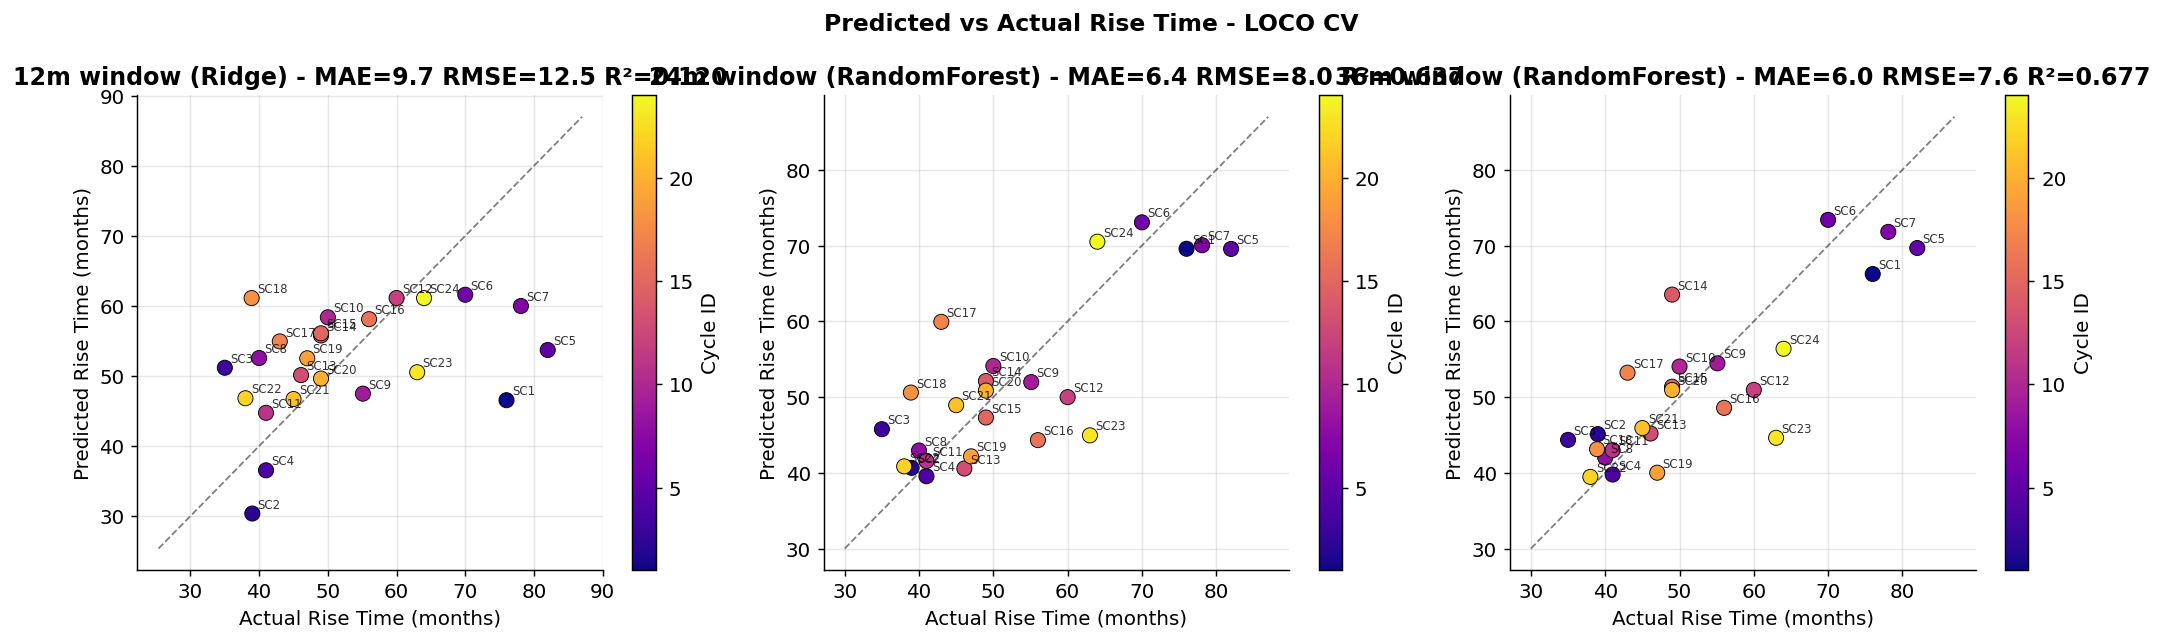

Saved: plots/phase4_pred_vs_actual.png


In [43]:
# ── Plot 1: Predicted vs Actual rise time ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, w in zip(axes, [12, 24, 36]):
    mname = best_per_window[w]
    loco  = all_loco_preds[(w, mname)]
    mae   = mean_absolute_error(loco["y_true"], loco["y_pred"])
    rmse  = np.sqrt(mean_squared_error(loco["y_true"], loco["y_pred"]))
    r2    = r2_score(loco["y_true"], loco["y_pred"])

    lo = min(loco["y_true"].min(), loco["y_pred"].min()) - 5
    hi = max(loco["y_true"].max(), loco["y_pred"].max()) + 5
    ax.plot([lo,hi],[lo,hi],"k--",lw=1,alpha=0.5,label="Perfect")
    sc = ax.scatter(loco["y_true"], loco["y_pred"],
                    c=loco["Cycle_ID"], cmap="plasma", s=70,
                    edgecolors="k", linewidths=0.5, zorder=3)
    for _, row in loco.iterrows():
        ax.annotate(f"SC{int(row['Cycle_ID'])}", (row["y_true"], row["y_pred"]),
                    fontsize=6.5, xytext=(3,3), textcoords="offset points", alpha=0.8)

    ax.set_xlabel("Actual Rise Time (months)")
    ax.set_ylabel("Predicted Rise Time (months)")
    ax.set_title(f"{w}m window ({mname}) - MAE={mae:.1f} RMSE={rmse:.1f} R²={r2:.3f}", fontweight="bold")
    plt.colorbar(sc, ax=ax, label="Cycle ID")

plt.suptitle("Predicted vs Actual Rise Time - LOCO CV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/phase4_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/phase4_pred_vs_actual.png")


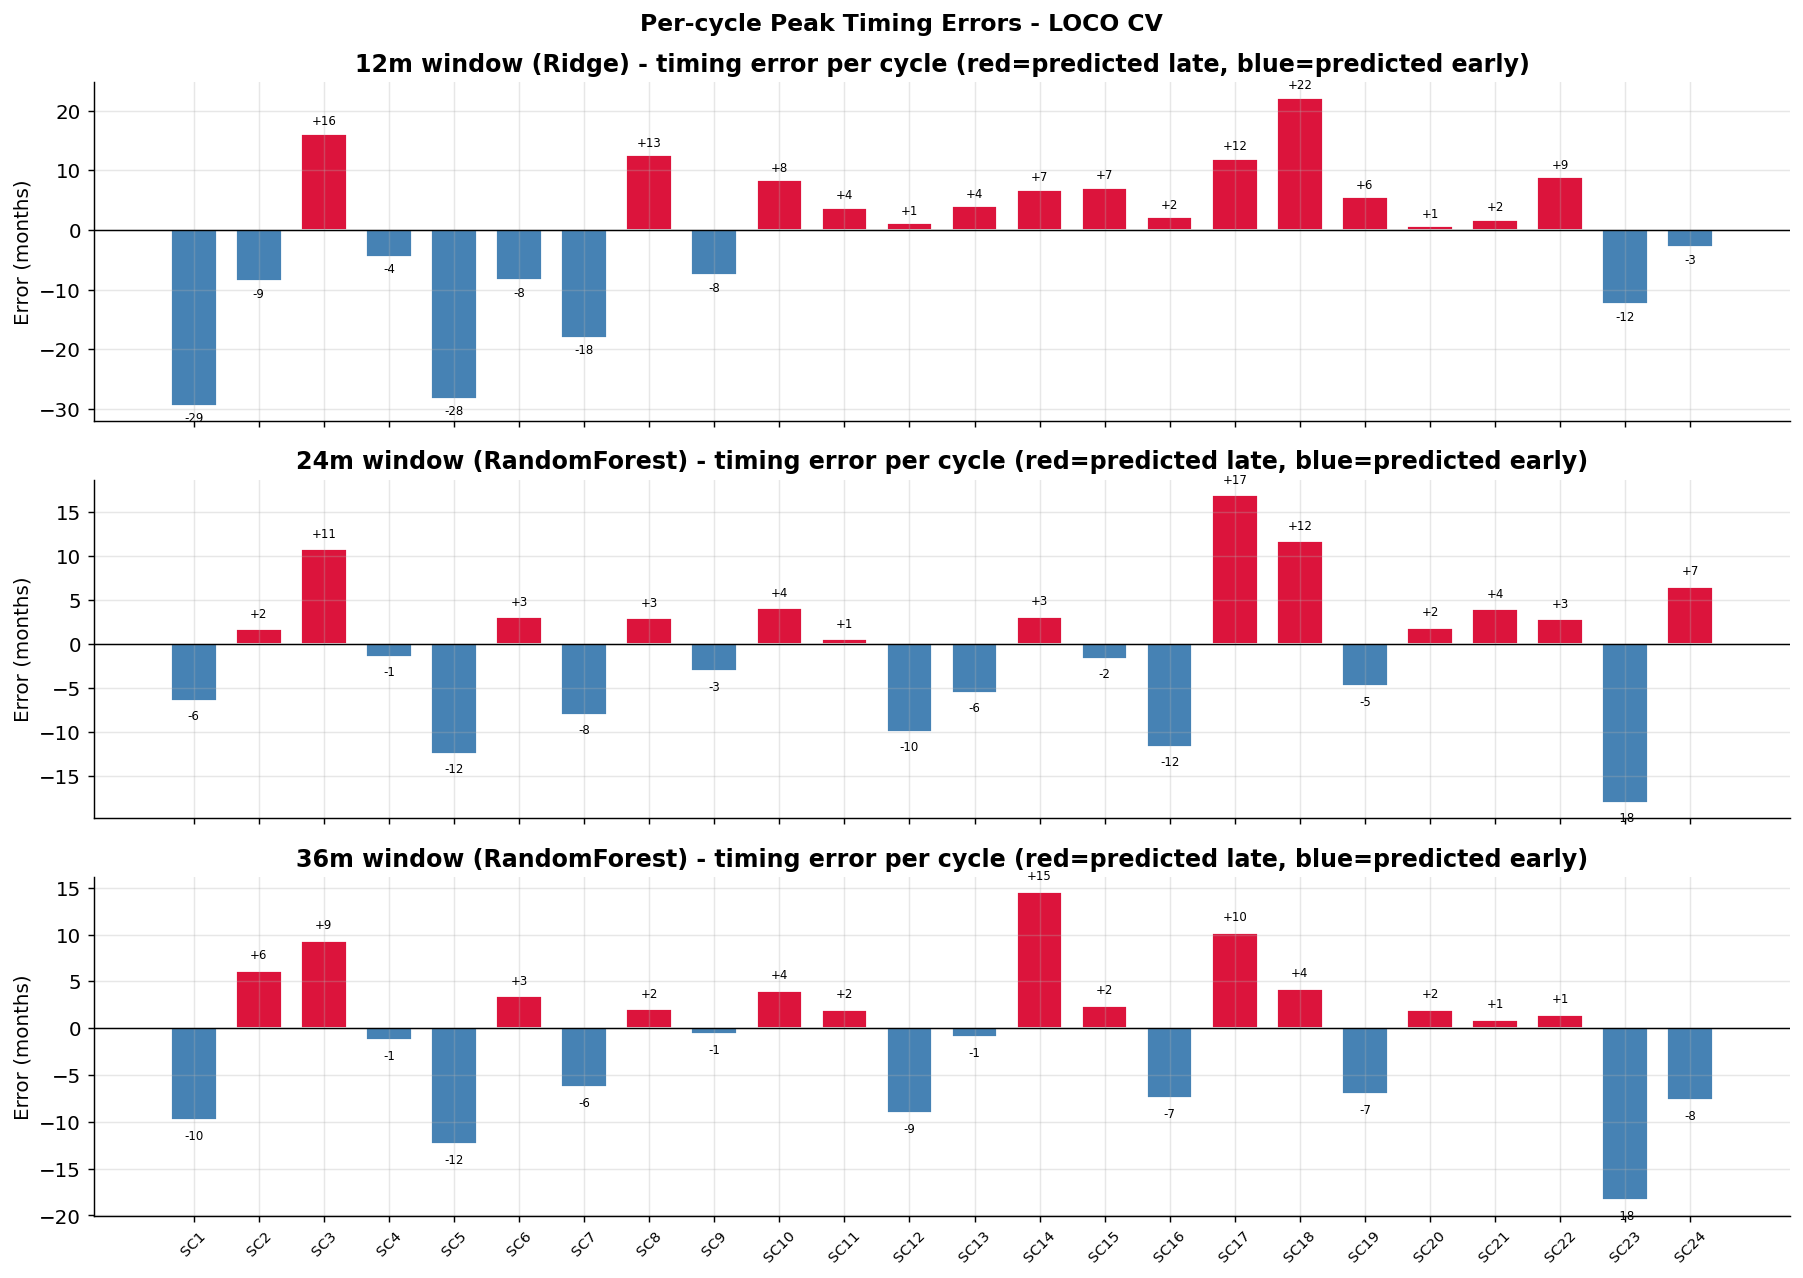

Saved: plots/phase4_per_cycle_errors.png


In [44]:
# ── Plot 2: Per-cycle timing errors ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, w in zip(axes, [12, 24, 36]):
    mname = best_per_window[w]
    loco  = all_loco_preds[(w, mname)].sort_values("Cycle_ID")
    colors = ["crimson" if e > 0 else "steelblue" for e in loco["error"]]
    bars = ax.bar(loco["Cycle_ID"], loco["error"], color=colors, edgecolor="white", width=0.7)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Error (months)")
    ax.set_title(f"{w}m window ({mname}) - timing error per cycle (red=predicted late, blue=predicted early)", fontweight="bold")
    ax.set_xticks(loco["Cycle_ID"])
    ax.set_xticklabels([f"SC{int(c)}" for c in loco["Cycle_ID"]], rotation=45, fontsize=8)
    for bar, val in zip(bars, loco["error"]):
        ax.text(bar.get_x()+bar.get_width()/2,
                val + (1 if val >= 0 else -1),
                f"{val:+.0f}", ha="center",
                va="bottom" if val >= 0 else "top", fontsize=6.5)

plt.suptitle("Per-cycle Peak Timing Errors - LOCO CV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/phase4_per_cycle_errors.png", dpi=150)
plt.show()
print("Saved: plots/phase4_per_cycle_errors.png")


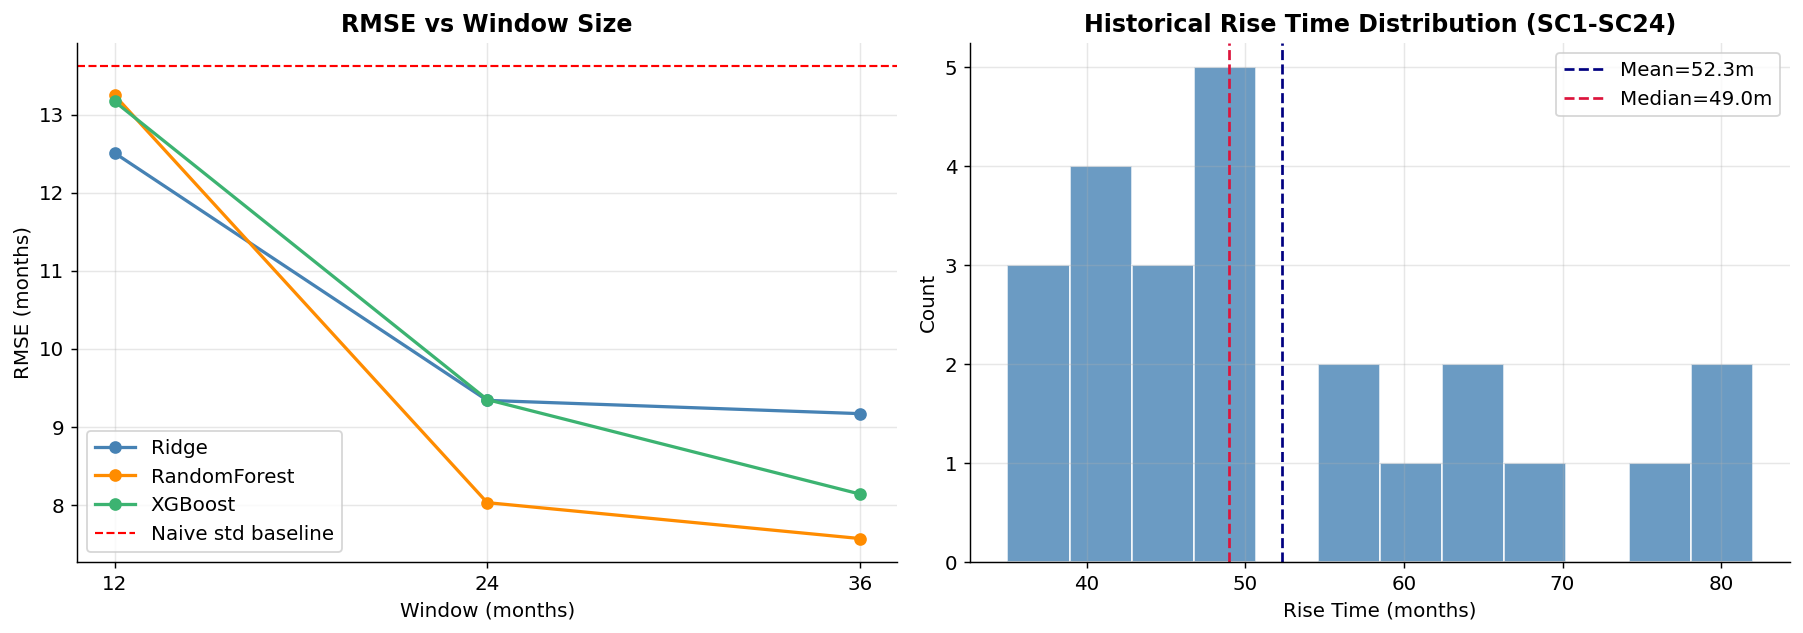

Saved: plots/phase4_rmse_and_dist.png


In [45]:
# ── Plot 3: RMSE comparison + rise time distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE by window
ax = axes[0]
for mname, color in zip(["Ridge","RandomForest","XGBoost"], ["steelblue","darkorange","mediumseagreen"]):
    subset = results_df[results_df["Model"].str.contains(mname)]
    if len(subset):
        windows = [int(r.split("_")[0][1:]) for r in subset["Model"]]
        ax.plot(windows, subset["RMSE"].values, marker="o", lw=1.8, color=color, label=mname)
ax.axhline(comp[TARGET].std(), color="red", lw=1.2, linestyle="--", label="Naive std baseline")
ax.set_xlabel("Window (months)")
ax.set_ylabel("RMSE (months)")
ax.set_xticks([12, 24, 36])
ax.set_title("RMSE vs Window Size", fontweight="bold")
ax.legend()

# Rise time distribution
ax2 = axes[1]
ax2.hist(comp[TARGET], bins=12, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(comp[TARGET].mean(), color="navy", lw=1.5, linestyle="--",
            label=f"Mean={comp[TARGET].mean():.1f}m")
ax2.axvline(comp[TARGET].median(), color="crimson", lw=1.5, linestyle="--",
            label=f"Median={comp[TARGET].median():.1f}m")
ax2.set_xlabel("Rise Time (months)")
ax2.set_ylabel("Count")
ax2.set_title("Historical Rise Time Distribution (SC1-SC24)", fontweight="bold")
ax2.legend()

plt.tight_layout()
plt.savefig("plots/phase4_rmse_and_dist.png", dpi=150)
plt.show()
print("Saved: plots/phase4_rmse_and_dist.png")


## SC25 Timing Forecast

In [46]:
sc25_full = pd.read_csv("../data/Cycle_Database.csv",
                         parse_dates=["Start_Date","End_Date","Peak_Date"])
sc25 = sc25_full[sc25_full["Cycle_ID"] == 25].iloc[0]

print("SC25 Timing Forecasts with 80% Prediction Intervals")
print("=" * 60)

sc25_timing = {}
for w in [12, 24, 36]:
    feats  = get_features(w)
    mname  = best_per_window[w]
    mfn    = models[mname]
    loco   = all_loco_preds[(w, mname)]

    # Train on ALL completed cycles
    X_train = comp[feats].values.copy()
    y_train = comp[TARGET].values

    growth_indices = [i for i, c in enumerate(feats) if "growth_rate" in c]
    for idx in growth_indices:
        X_train[:, idx] = np.clip(X_train[:, idx], -5, 50)

    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)

    model = mfn()
    model.fit(X_train, y_train)

    X_sc25 = sc25[feats].values.reshape(1,-1).copy()
    for idx in growth_indices:
        X_sc25[:, idx] = np.clip(X_sc25[:, idx], -5, 50)
    X_sc25 = scaler.transform(X_sc25)

    pred_months = model.predict(X_sc25)[0]
    sc25_timing[w] = pred_months

    # CI from LOCO residuals
    residuals = loco["error"].values
    ci_low    = np.percentile(residuals, 10)
    ci_high   = np.percentile(residuals, 90)

    # Convert to calendar date
    pred_date    = sc25["Start_Date"] + pd.DateOffset(months=int(round(pred_months)))
    ci_date_low  = sc25["Start_Date"] + pd.DateOffset(months=int(round(pred_months + ci_low)))
    ci_date_high = sc25["Start_Date"] + pd.DateOffset(months=int(round(pred_months + ci_high)))

    print(f"  {w}m ({mname}): {pred_months:.1f} months from start")
    print(f"    Predicted peak month : {pred_date.strftime('%Y-%m')}")
    print(f"    80% CI               : {ci_date_low.strftime('%Y-%m')} - {ci_date_high.strftime('%Y-%m')}")

ens_months = np.mean(list(sc25_timing.values()))
ens_date   = sc25["Start_Date"] + pd.DateOffset(months=int(round(ens_months)))
print("")
print(f"  Ensemble ({ens_months:.1f} months): predicted peak {ens_date.strftime('%Y-%m')}")
print(f"  SC25 Start: {sc25['Start_Date'].strftime('%Y-%m')}")

SC25 Timing Forecasts with 80% Prediction Intervals
  12m (Ridge): 60.5 months from start
    Predicted peak month : 2024-12
    80% CI               : 2023-08 - 2026-01
  24m (RandomForest): 68.3 months from start
    Predicted peak month : 2025-08
    80% CI               : 2024-09 - 2026-06
  36m (RandomForest): 63.5 months from start
    Predicted peak month : 2025-04
    80% CI               : 2024-06 - 2025-12

  Ensemble (64.1 months): predicted peak 2025-04
  SC25 Start: 2019-12


## Save Results

In [47]:
import os
os.makedirs("results", exist_ok=True)

results_df.to_csv("results/phase4_results.csv", index=False)
print("Saved: results/phase4_results.csv")

for w in [12, 24, 36]:
    mname = best_per_window[w]
    all_loco_preds[(w, mname)].to_csv(f"results/phase4_loco_w{w}.csv", index=False)
    print(f"Saved: results/phase4_loco_w{w}.csv")

timing_df = pd.DataFrame([
    {"Window_months": w, "Best_model": best_per_window[w],
     "SC25_Rise_Time_forecast": round(sc25_timing[w],1)}
    for w in [12, 24, 36]
])
timing_df.to_csv("results/phase4_sc25_timing_forecast.csv", index=False)
print("Saved: results/phase4_sc25_timing_forecast.csv")
print()
print(timing_df.to_string(index=False))


Saved: results/phase4_results.csv
Saved: results/phase4_loco_w12.csv
Saved: results/phase4_loco_w24.csv
Saved: results/phase4_loco_w36.csv
Saved: results/phase4_sc25_timing_forecast.csv

 Window_months   Best_model  SC25_Rise_Time_forecast
            12        Ridge                     60.5
            24 RandomForest                     68.3
            36 RandomForest                     63.5


## Phase 4 Complete

| Output | Description |
|--------|-------------|
| `results/phase4_results.csv` | LOCO CV MAE, RMSE, R² for all model/window combos |
| `results/phase4_loco_w12/24/36.csv` | Per-cycle predictions from best model at each window |
| `results/phase4_sc25_timing_forecast.csv` | SC25 rise time forecasts |
| `plots/phase4_pred_vs_actual.png` | Predicted vs actual rise time |
| `plots/phase4_per_cycle_errors.png` | Per-cycle timing error bars |
| `plots/phase4_rmse_and_dist.png` | RMSE comparison + rise time distribution |

**Next:** Phase 5 — Trajectory Forecasting (GRU / LSTM / TCN)


In [48]:
print(results_df.to_string(index=False))

           Model   MAE  RMSE     R2
w36_RandomForest  5.96  7.57 0.6772
w24_RandomForest  6.39  8.03 0.6370
     w36_XGBoost  6.02  8.14 0.6273
       w36_Ridge  7.18  9.17 0.5266
       w24_Ridge  7.59  9.34 0.5095
     w24_XGBoost  7.42  9.35 0.5087
       w12_Ridge  9.71 12.51 0.1203
     w12_XGBoost  9.75 13.17 0.0247
w12_RandomForest 10.17 13.25 0.0130


In [49]:
# should already have printed when you ran the notebook
# if not, run this:
sample_i  = comp.index[5]
train_idx = [j for j in comp.index if j != sample_i]
print(f"Train cycles : {list(comp.loc[train_idx, 'Cycle_ID'].astype(int))}")
print(f"Test  cycle  : {int(comp.loc[sample_i, 'Cycle_ID'])}")
assert int(comp.loc[sample_i, 'Cycle_ID']) not in list(comp.loc[train_idx, 'Cycle_ID'].astype(int))
print("Assertion passed")

Train cycles : [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Test  cycle  : 6
Assertion passed


In [50]:
print(results_df.to_string(index=False))

           Model   MAE  RMSE     R2
w36_RandomForest  5.96  7.57 0.6772
w24_RandomForest  6.39  8.03 0.6370
     w36_XGBoost  6.02  8.14 0.6273
       w36_Ridge  7.18  9.17 0.5266
       w24_Ridge  7.59  9.34 0.5095
     w24_XGBoost  7.42  9.35 0.5087
       w12_Ridge  9.71 12.51 0.1203
     w12_XGBoost  9.75 13.17 0.0247
w12_RandomForest 10.17 13.25 0.0130


In [51]:
print("=" * 65)
print("  EXTENDED EVALUATION — fold-wise stats & prediction intervals")
print("=" * 65)

best_per_window = {}
for w in [12, 24, 36]:
    w_res  = results_df[results_df["Model"].str.startswith(f"w{w}_")]
    best   = w_res.sort_values("RMSE").iloc[0]["Model"]
    mname  = best.replace(f"w{w}_","")
    best_per_window[w] = mname

    loco       = all_loco_preds[(w, mname)]
    abs_errors = loco["abs_error"].values
    residuals  = loco["error"].values
    ci_low     = np.percentile(residuals, 10)
    ci_high    = np.percentile(residuals, 90)

    print("")
    print(f"Window={w}m  Best={mname}")
    print(f"  MAE={mean_absolute_error(loco['y_true'],loco['y_pred']):.2f}  "
          f"RMSE={np.sqrt(mean_squared_error(loco['y_true'],loco['y_pred'])):.2f}  "
          f"R²={r2_score(loco['y_true'],loco['y_pred']):.4f}")
    print(f"  Fold-wise MAE: mean={abs_errors.mean():.2f}, std={abs_errors.std():.2f} months")
    print(f"  80% prediction interval (residuals): [{ci_low:+.1f}, {ci_high:+.1f}] months")

print("")
print(f"Best model per window: {best_per_window}")

  EXTENDED EVALUATION — fold-wise stats & prediction intervals

Window=12m  Best=Ridge
  MAE=9.71  RMSE=12.51  R²=0.1203
  Fold-wise MAE: mean=9.71, std=7.88 months
  80% prediction interval (residuals): [-16.4, +12.4] months

Window=24m  Best=RandomForest
  MAE=6.39  RMSE=8.03  R²=0.6370
  Fold-wise MAE: mean=6.39, std=4.87 months
  80% prediction interval (residuals): [-11.2, +9.5] months

Window=36m  Best=RandomForest
  MAE=5.96  RMSE=7.57  R²=0.6772
  Fold-wise MAE: mean=5.96, std=4.67 months
  80% prediction interval (residuals): [-9.5, +8.4] months

Best model per window: {12: 'Ridge', 24: 'RandomForest', 36: 'RandomForest'}


In [52]:
print(list(all_loco_preds.keys()))

[(12, 'Ridge'), (12, 'RandomForest'), (12, 'XGBoost'), (24, 'Ridge'), (24, 'RandomForest'), (24, 'XGBoost'), (36, 'Ridge'), (36, 'RandomForest'), (36, 'XGBoost')]


In [53]:
loco_df = all_loco_preds[(36, "RandomForest")]
print(loco_df[loco_df["Cycle_ID"] == 24])

    Cycle_ID  y_true     y_pred     error  abs_error
23        24    64.0  56.377695 -7.622305   7.622305


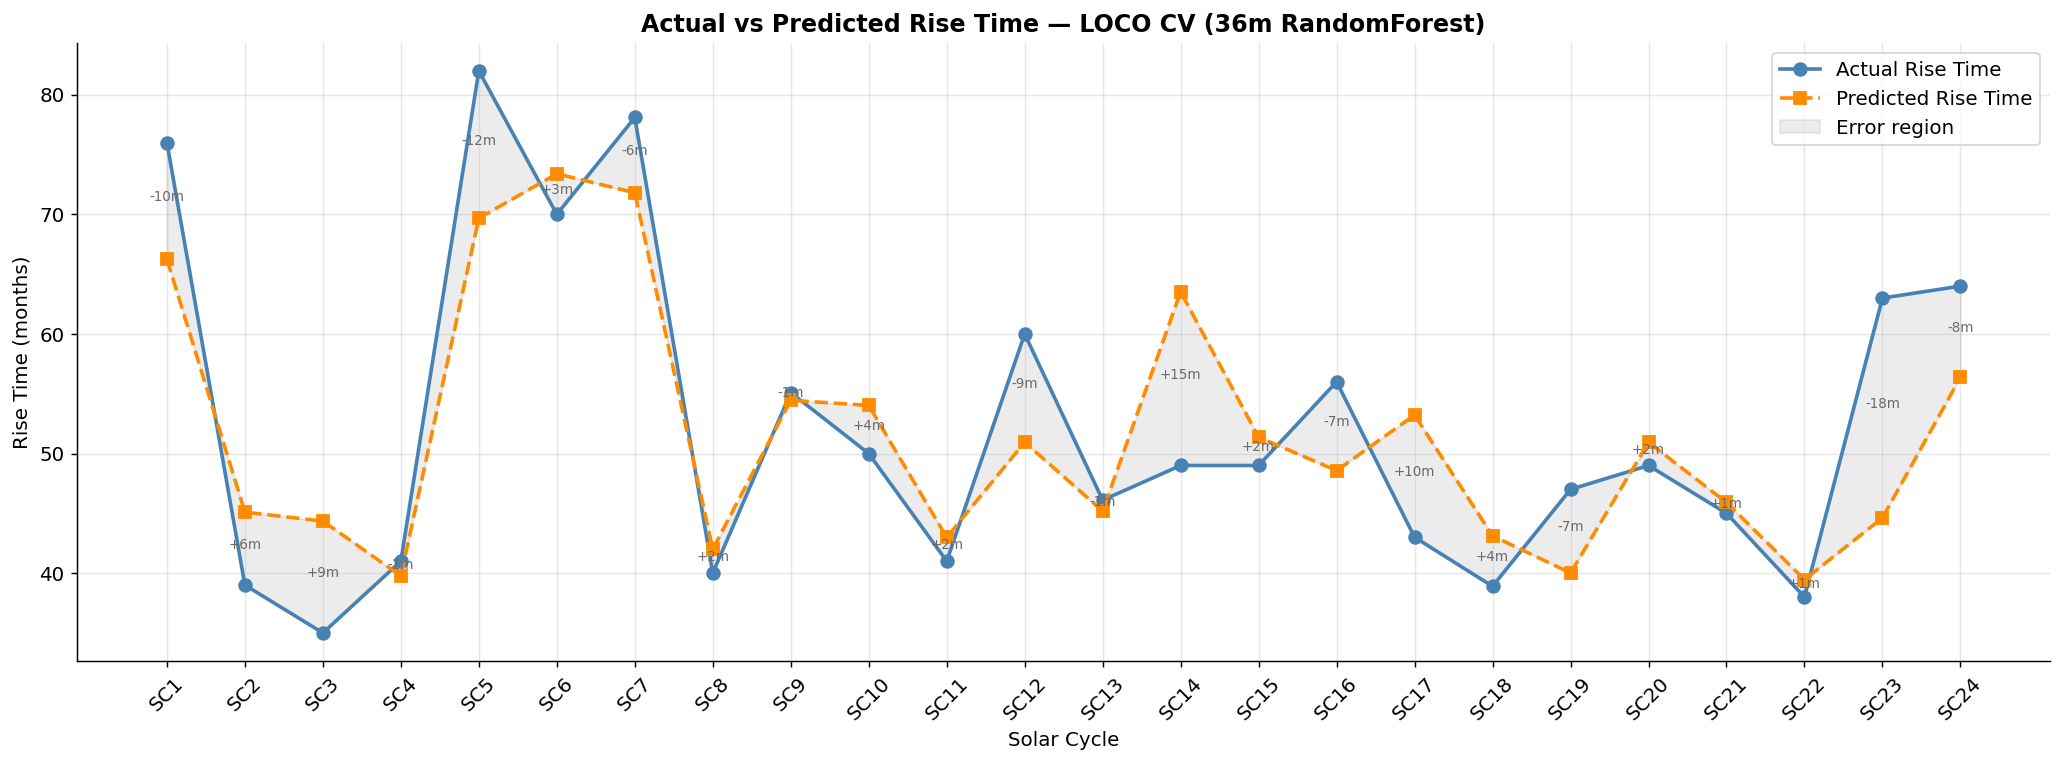

Saved.


In [54]:
loco_df = all_loco_preds[(36, "RandomForest")].sort_values("Cycle_ID").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))

x = loco_df["Cycle_ID"]
ax.plot(x, loco_df["y_true"],  "o-", color="steelblue",  lw=2, markersize=7, label="Actual Rise Time")
ax.plot(x, loco_df["y_pred"],  "s--", color="darkorange", lw=2, markersize=7, label="Predicted Rise Time")

# shade the error
ax.fill_between(x, loco_df["y_true"], loco_df["y_pred"],
                alpha=0.15, color="gray", label="Error region")

# annotate error on each cycle
for _, row in loco_df.iterrows():
    ax.annotate(f"{row['error']:+.0f}m",
                xy=(row["Cycle_ID"], (row["y_true"] + row["y_pred"]) / 2),
                fontsize=7.5, ha="center", color="dimgray")

ax.set_xticks(x)
ax.set_xticklabels([f"SC{int(c)}" for c in x], rotation=45)
ax.set_xlabel("Solar Cycle")
ax.set_ylabel("Rise Time (months)")
ax.set_title("Actual vs Predicted Rise Time — LOCO CV (36m RandomForest)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plots/phase4_actual_vs_predicted_all_cycles.png", dpi=150)
plt.show()
print("Saved.")